## Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv('ocean_wave.csv')
df.head()

,Date/Time,Hs,Hmax,Tz,Tp,Peak Direction,SST
0,01/01/2017 00:00,-99.900,-99.90,-99.900,-99.900,-99.9,-99.90
1,01/01/2017 00:30,0.875,1.39,4.421,4.506,-99.9,-99.90
2,01/01/2017 01:00,0.763,1.15,4.520,5.513,49.0,25.65
3,01/01/2017 01:30,0.770,1.41,4.582,5.647,75.0,25.50
4,01/01/2017 02:00,0.747,1.16,4.515,5.083,91.0,25.45


In [3]:
# Deleting NaN values
df.replace(-99.90, np.nan, inplace=True)
df.drop('Date/Time', axis=1, inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,Hs,Hmax,Tz,Tp,Peak Direction,SST
0,0.763,1.15,4.520,5.513,49.0,25.65
1,0.770,1.41,4.582,5.647,75.0,25.50
2,0.747,1.16,4.515,5.083,91.0,25.45
3,0.718,1.61,4.614,6.181,68.0,25.45
4,0.707,1.34,4.568,4.705,73.0,25.50


## Visualization of the Features

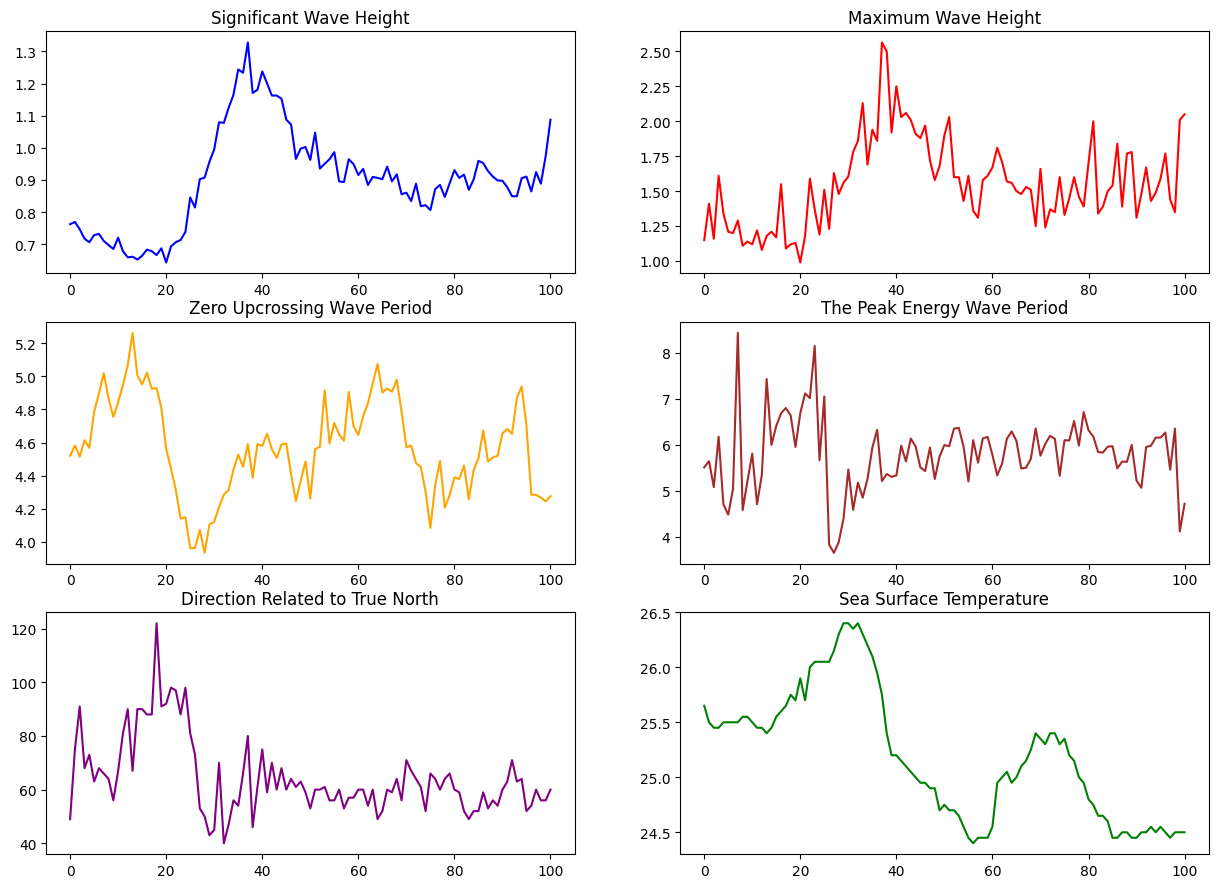

In [4]:
df_graph = df.loc[0:100]

plt.figure(figsize=(15,22))
plt.subplot(6,2,1)
plt.plot(df_graph['Hs'], color='blue')
plt.title('Significant Wave Height')

plt.subplot(6,2,2)
plt.plot(df_graph['Hmax'], color='red')
plt.title('Maximum Wave Height')

plt.subplot(6,2,3)
plt.plot(df_graph['Tz'], color='orange')
plt.title('Zero Upcrossing Wave Period')

plt.subplot(6,2,4)
plt.plot(df_graph['Tp'], color='brown')
plt.title('The Peak Energy Wave Period')

plt.subplot(6,2,5)
plt.plot(df_graph['Peak Direction'], color='purple')
plt.title('Direction Related to True North')

plt.subplot(6,2,6)
plt.plot(df_graph['SST'], color='green')
plt.title('Sea Surface Temperature')
plt.show();

## Initial Statistics

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43454 entries, 0 to 43453
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hs              43454 non-null  float64
 1   Hmax            43454 non-null  float64
 2   Tz              43454 non-null  float64
 3   Tp              43454 non-null  float64
 4   Peak Direction  43454 non-null  float64
 5   SST             43454 non-null  float64
dtypes: float64(6)
memory usage: 2.0 MB
None


In [6]:
df.describe()

,Hs,Hmax,Tz,Tp,Peak Direction,SST
count,43454.000000,43454.000000,43454.000000,43454.000000,43454.000000,43454.000000
mean,1.237799,2.090125,5.619685,9.011972,98.626594,23.949641
std,0.528608,0.897640,0.928533,2.390107,24.275165,2.231022
min,0.294000,0.510000,3.076000,2.720000,5.000000,19.800000
25%,0.839000,1.410000,4.981000,7.292000,85.000000,21.900000
50%,1.130000,1.900000,5.530000,8.886000,101.000000,23.950000
75%,1.544000,2.600000,6.166000,10.677000,116.000000,26.050000
max,4.257000,7.906000,10.921000,21.121000,358.000000,28.650000


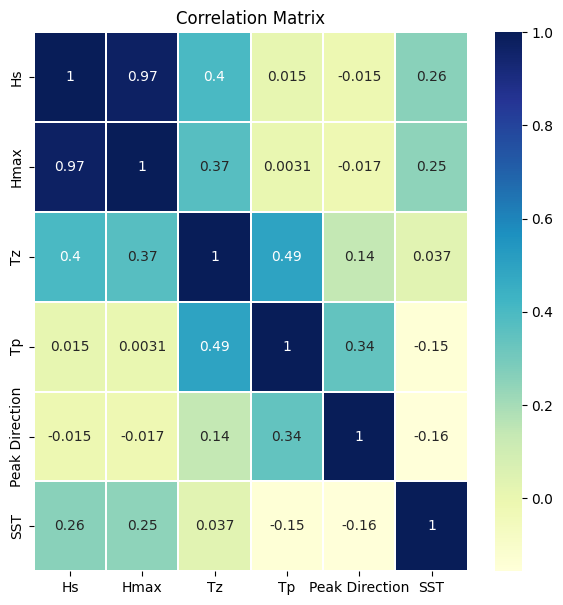

In [7]:
plt.figure(figsize=(7,7))
sns.heatmap(df.corr(), linewidth=.1, annot=True, cmap='YlGnBu')
plt.title('Correlation Matrix')
plt.show();

## Feature Scaling

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Scaling all the values between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
data = scaler.fit_transform(df)
print('Shape of the scaled data matrix: ', data.shape)

Shape of the scaled data matrix:  (43454, 6)


## Train and Test Split

In [9]:
# Separete data into 2 groups for train and test
train = data[:42000,]
test = data[42000: ,]

# Shapes of our datasets
print('Shape of train data: ', train.shape)
print('Shape of test data: ', test.shape)

Shape of train data:  (42000, 6)
Shape of test data:  (1454, 6)


## LSTM specific

In [10]:
# Separete every 30 samples as the input and get the 31st sample as the output.
def prepare_data(data):
    databatch = 30
    x_list = []
    y_list = []

    for i in range(len(data)-databatch-1):
        x_list.append(data[i:i+databatch])
        y_list.append(data[i+databatch+1])

    X_data = np.array(x_list)
    X_data = np.reshape(X_data, (X_data.shape[0], X_data.shape[2], X_data.shape[1]))
    y_data = np.array(y_list)

    return X_data, y_data

In [11]:
# Executing the separation
X_train, y_train = prepare_data(train)
X_test, y_test = prepare_data(test)
print('X_train Shape : ', X_train.shape, 'y_train shape :', y_train.shape)
print('X_test Shape  : ', X_test.shape, ' y_test shape  :', y_test.shape)

X_train Shape :  (41969, 6, 30) y_train shape : (41969, 6)
X_test Shape  :  (1423, 6, 30)  y_test shape  : (1423, 6)


## Creating the LSTM Model

In [12]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input
from keras.optimizers import Adam

def lstm_model(x_data, y_data, num_epochs, batch_size, learning_rate):
    model = Sequential()
    model.add(Input(shape=(x_data.shape[1], x_data.shape[2])))
    model.add(LSTM(32, return_sequences=True))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(10))
    model.add(Dense(6))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

    history = model.fit(x_data, y_data, validation_split=0.25, epochs=num_epochs, batch_size=batch_size)
    return model, history


In [13]:
history = lstm_model(X_train, y_train, num_epochs=15, batch_size=200, learning_rate=.001)

Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0211 - mean_squared_error: 0.0211 - val_loss: 0.0040 - val_mean_squared_error: 0.0040
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0032 - val_mean_squared_error: 0.0032
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0028 - val_mean_squared_error: 0.0028
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0024 - val_mean_squared_error: 0.0024
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0021 - val_mean_squared_error: 0.0021
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0019 - val_mean_squared_error: 0.0019
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_los

## Visualization of the Learning

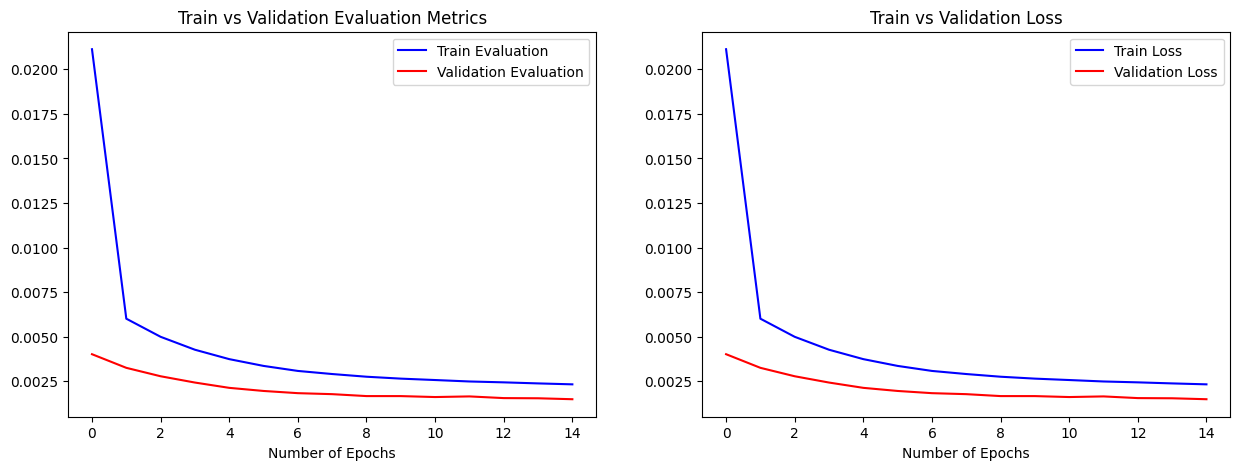

In [14]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(history[1].history['mean_squared_error'], color='blue', label='Train Evaluation')
plt.plot(history[1].history['val_mean_squared_error'], color='red', label='Validation Evaluation')
plt.title('Train vs Validation Evaluation Metrics')
plt.xlabel('Number of Epochs')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history[1].history['loss'], color='blue', label='Train Loss')
plt.plot(history[1].history['val_loss'], color='red', label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Number of Epochs')
plt.legend()
plt.show();

## Predictions

In [15]:
# Defining function to predict datas
def predicting(data, y_real):
    predicted_data = history[0].predict(data)
    # Invert scaling process to get the normal values range for the features
    predicted_data = scaler.inverse_transform(predicted_data)
    y_real = scaler.inverse_transform(y_real)

    return predicted_data, y_real

In [16]:
# Executing predictions
train_prediction, y_train = predicting(X_train, y_train)
test_prediction, y_test = predicting(X_test, y_test)

1312/1312 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## Evaluating the Model Success

In [17]:
# Defining function to investigate the root of mean squared errors (RMSE) between predicted and real data

import math
from sklearn.metrics import mean_squared_error

def examine_rmse(y_data, predicted_data):
    Score_Hs = math.sqrt(mean_squared_error(y_data[:,0], predicted_data[:,0]))
    Score_Hmax = math.sqrt(mean_squared_error(y_data[:,1], predicted_data[:,1]))
    Score_Tz = math.sqrt(mean_squared_error(y_data[:,2], predicted_data[:,2]))
    Score_Tp = math.sqrt(mean_squared_error(y_data[:,3], predicted_data[:,3]))
    Score_Dir = math.sqrt(mean_squared_error(y_data[:,4], predicted_data[:,4]))
    Score_SST = math.sqrt(mean_squared_error(y_data[:,5], predicted_data[:,5]))

    print('RMSE_Hs       : ', Score_Hs)
    print('RMSE_Hmax     : ', Score_Hmax)
    print('RMSE_Tz       : ', Score_Tz)
    print('RMSE_Tp       : ', Score_Tp)
    print('RMSE_Direction: ', Score_Dir)
    print('RMSE_SST      : ', Score_SST)

In [18]:
# Executing the RMSE comparison
print('Trainin Data Errors')
print(examine_rmse(y_train, train_prediction),'\n')
print('Test Data Errors')
print(examine_rmse(y_test, test_prediction))

Trainin Data Errors
RMSE_Hs       :  0.09943251021270624
RMSE_Hmax     :  0.2617400197478263
RMSE_Tz       :  0.3244109177433958
RMSE_Tp       :  1.3235292172295263
RMSE_Direction:  13.761421841016078
RMSE_SST      :  0.21593953465002602
None 

Test Data Errors
RMSE_Hs       :  0.0886192802032509
RMSE_Hmax     :  0.24376786032549136
RMSE_Tz       :  0.34260799091391836
RMSE_Tp       :  1.957856974055799
RMSE_Direction:  14.49121490230661
RMSE_SST      :  0.20302452926294481
None


## Visualization of the Real and Predicted Values

For the ease of understanding the model, the real and predicted datas are limited by 123 samples (Samples from 1300-1423).

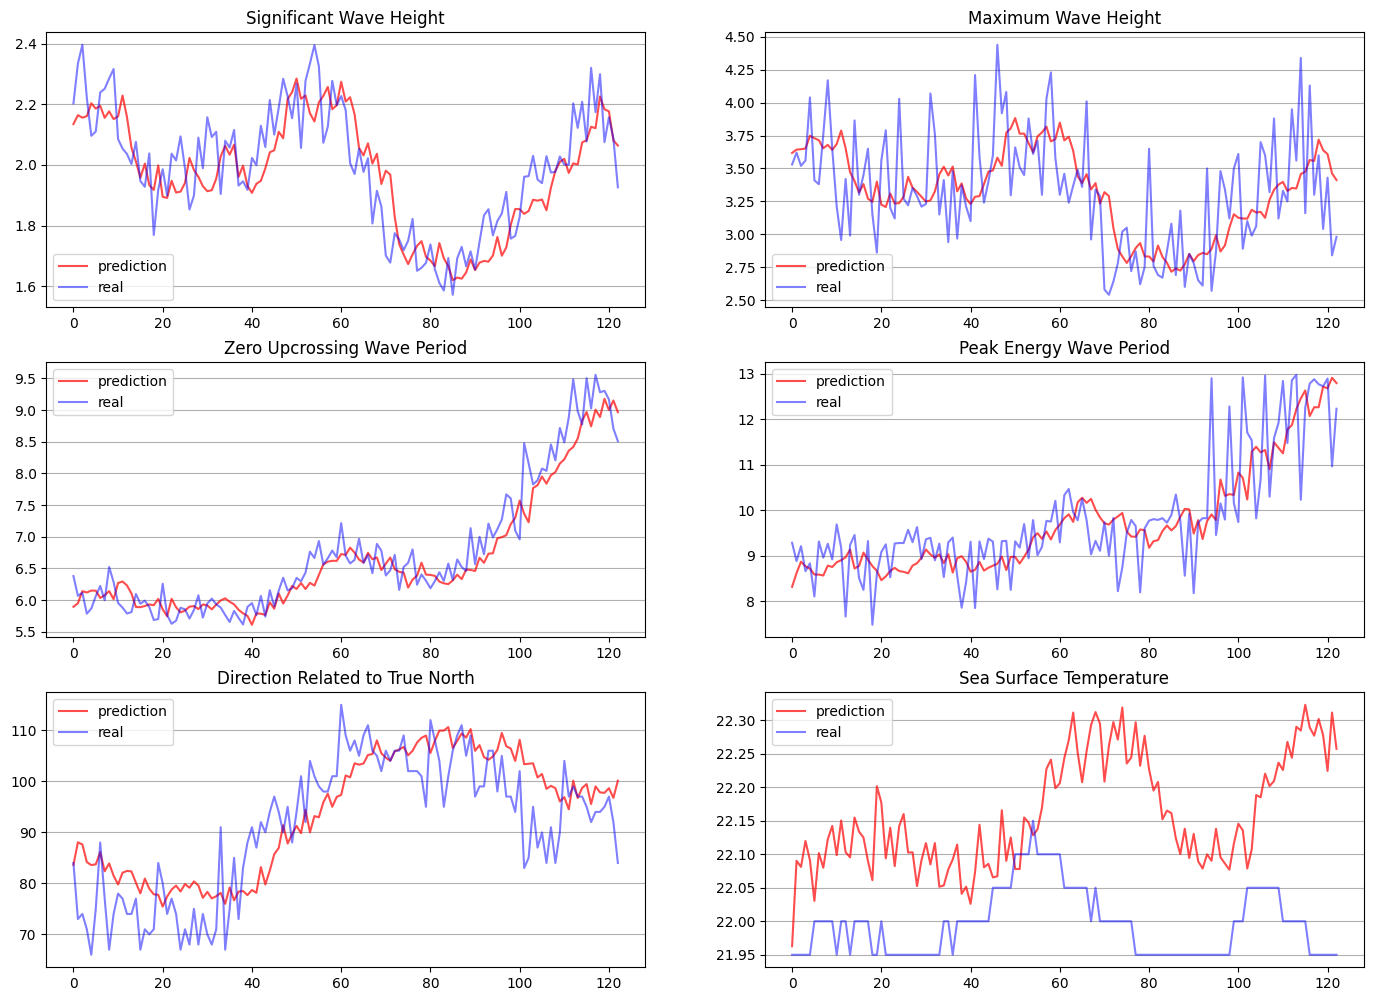

In [19]:
plt.figure(figsize=(17,25))


plt.subplot(6,2,1)
plt.plot(test_prediction[1300:,0], color='red', alpha=0.7, label='prediction')
plt.plot(y_test[1300:,0], color='blue', alpha=0.5, label='real')
plt.title('Significant Wave Height')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6,2,2)
plt.plot(test_prediction[1300:,1], color='red', alpha=0.7, label='prediction')
plt.plot(y_test[1300:,1], color='blue', alpha=0.5, label='real')
plt.title('Maximum Wave Height')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6,2,3)
plt.plot(test_prediction[1300:,2], color='red', alpha=0.7, label='prediction')
plt.plot(y_test[1300:,2], color='blue', alpha=0.5, label='real')
plt.title('Zero Upcrossing Wave Period')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6,2,4)
plt.plot(test_prediction[1300:,3], color='red', alpha=0.7, label='prediction')
plt.plot(y_test[1300:,3], color='blue', alpha=0.5, label='real')
plt.title('Peak Energy Wave Period')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6,2,5)
plt.plot(test_prediction[1300:,4], color='red', alpha=0.7, label='prediction')
plt.plot(y_test[1300:,4], color='blue', alpha=0.5, label='real')
plt.title('Direction Related to True North')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6,2,6)
plt.plot(test_prediction[1300:,5], color='red', alpha=0.7, label='prediction')
plt.plot(y_test[1300:,5], color='blue', alpha=0.5, label='real')
plt.title('Sea Surface Temperature')
plt.legend()
plt.grid(True, axis='y')
plt.show();

# Data Preparation for GRU

In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def prepare_data_gru_fixed(df_original, sequence_length=30):
    """
    CORRECTED: Prepare data for GRU with proper directional feature handling
    """
    print("="*60)
    print("CORRECTED GRU DATA PREPARATION")
    print("="*60)

    # 1. Create copy
    df = df_original.copy()

    # 2. Convert direction to radians and then to sin/cos
    print("\n1. Converting direction to sin/cos...")
    direction_rad = np.radians(df['Peak Direction'])
    df['Peak Direction_sin'] = np.sin(direction_rad)
    df['Peak Direction_cos'] = np.cos(direction_rad)

    # Reorder columns to: Hs, Hmax, Tz, Tp, Dir_sin, Dir_cos, SST
    columns_order = ['Hs', 'Hmax', 'Tz', 'Tp', 'Peak Direction_sin', 'Peak Direction_cos', 'SST']
    df = df[columns_order]

    print(f"New columns: {df.columns.tolist()}")
    print(f"Number of features: {len(df.columns)}")

    # 3. Scale data (0 to 1 range)
    print("\n2. Scaling data...")
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df)

    print(f"Scaled data shape: {scaled_data.shape}")

    # 4. Train/Test split (same as LSTM: 42000 train, rest test)
    print("\n3. Splitting data...")
    train_data = scaled_data[:42000]
    test_data = scaled_data[42000:]

    print(f"Train shape: {train_data.shape}")
    print(f"Test shape: {test_data.shape}")

    # 5. Create sequences
    print(f"\n4. Creating sequences (length={sequence_length})...")

    def create_sequences(data):
        X, y = [], []
        for i in range(len(data) - sequence_length - 1):
            X.append(data[i:i + sequence_length])
            y.append(data[i + sequence_length + 1])

        X = np.array(X)
        y = np.array(y)

        # Reshape to (samples, features, timesteps)
        X = np.transpose(X, (0, 2, 1))

        return X, y

    X_train, y_train = create_sequences(train_data)
    X_test, y_test = create_sequences(test_data)

    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")

    return X_train, y_train, X_test, y_test, scaler, columns_order

# Prepare data
print("\n" + "="*60)
print("PREPARING DATA")
print("="*60)
X_train_gru, y_train_gru, X_test_gru, y_test_gru, scaler_gru, feature_names = prepare_data_gru_fixed(df)


PREPARING DATA
CORRECTED GRU DATA PREPARATION

1. Converting direction to sin/cos...
New columns: ['Hs', 'Hmax', 'Tz', 'Tp', 'Peak Direction_sin', 'Peak Direction_cos', 'SST']
Number of features: 7

2. Scaling data...
Scaled data shape: (43454, 7)

3. Splitting data...
Train shape: (42000, 7)
Test shape: (1454, 7)

4. Creating sequences (length=30)...
X_train shape: (41969, 7, 30)
y_train shape: (41969, 7)
X_test shape: (1423, 7, 30)
y_test shape: (1423, 7)


# Split Data for Validation

In [21]:
# Split training data for validation
from sklearn.model_selection import train_test_split

print("\n" + "="*60)
print("SPLITTING FOR VALIDATION")
print("="*60)

# Use 20% of training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_gru, y_train_gru,
    test_size=0.2,
    random_state=42,
    shuffle=False  # Important for time series!
)

print(f"Training data: {X_train_split.shape}")
print(f"Validation data: {X_val_split.shape}")


SPLITTING FOR VALIDATION
Training data: (33575, 7, 30)
Validation data: (8394, 7, 30)


# GRU Model Implementation

In [22]:
from keras.layers import GRU, Input, Dense, Dropout, BatchNormalization
from keras.models import Sequential
from keras.regularizers import l1_l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam

def fixed_gru_model(x_train, y_train, x_val, y_val, num_epochs=100, batch_size=64, learning_rate=0.001):
    """
    FIXED GRU model implementation
    """
    print("\n" + "="*60)
    print("BUILDING GRU MODEL")
    print("="*60)

    n_features = x_train.shape[1]  # Should be 7
    n_timesteps = x_train.shape[2]  # Should be 30

    print(f"Input shape: ({n_timesteps} timesteps × {n_features} features)")
    print(f"Output shape: {n_features} features")

    model = Sequential()

    # Input layer
    model.add(Input(shape=(n_features, n_timesteps)))

    # First GRU layer
    model.add(GRU(128,
                  return_sequences=True,
                  kernel_regularizer=l1_l2(l1=0.001, l2=0.001),
                  recurrent_regularizer=l1_l2(l1=0.001, l2=0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))  # Increased dropout

    # Second GRU layer
    model.add(GRU(64,
                  return_sequences=True,
                  kernel_regularizer=l1_l2(l1=0.001, l2=0.001),
                  recurrent_regularizer=l1_l2(l1=0.001, l2=0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Third GRU layer
    model.add(GRU(32,
                  return_sequences=False,
                  kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Dense layers with activation
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(32, activation='relu'))

    # Output layer - CRITICAL: Must match number of features (7)
    model.add(Dense(n_features, name='output_layer'))

    # Compile with adjusted learning rate
    optimizer = Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(
        loss='mse',
        optimizer=optimizer,
        metrics=['mse', 'mae']
    )

    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        min_delta=0.0001,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        'best_gru_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    # Model summary
    print("\nModel Architecture:")
    print("-" * 40)
    model.summary()

    # Train model
    print("\n" + "="*60)
    print("TRAINING MODEL")
    print("="*60)

    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=num_epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )

    return model, history

# Train the model
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

gru_model, gru_history = fixed_gru_model(
    X_train_split, y_train_split,
    X_val_split, y_val_split,
    num_epochs=50,
    batch_size=128,  # Smaller batch size
    learning_rate=0.0005  # Lower learning rate
)


STARTING TRAINING

BUILDING GRU MODEL
Input shape: (30 timesteps × 7 features)
Output shape: 7 features

Model Architecture:
----------------------------------------


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 7, 128)         │        61,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 7, 64)          │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,671 (444.03 KB)

 Trainable params: 113,095 (441.78 KB)

 Non-trainable params: 576 (2.25 KB)


TRAINING MODEL
Epoch 1/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 5.2037 - mae: 0.5867 - mse: 0.6336
Epoch 1: val_loss improved from None to 1.66956, saving model to best_gru_model.keras

Epoch 1: finished saving model to best_gru_model.keras
263/263 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - loss: 3.6866 - mae: 0.4170 - mse: 0.3339 - val_loss: 1.6696 - val_mae: 0.1629 - val_mse: 0.0429 - learning_rate: 5.0000e-04
Epoch 2/50
262/263 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1.3823 - mae: 0.2242 - mse: 0.0843
Epoch 2: val_loss improved from 1.66956 to 0.66823, saving model to best_gru_model.keras

Epoch 2: finished saving model to best_gru_model.keras
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 1.1092 - mae: 0.2048 - mse: 0.0709 - val_loss: 0.6682 - val_mae: 0.1680 - val_mse: 0.0442 - learning_rate: 5.0000e-04
Epoch 3/50
262/263 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.5545 - mae: 0.1633 - mse: 0.0455
Epoch 3: val_loss improved from 0.66823 to 0.28567, saving model to bes

# Fixed Prediction and Evaluation Functions

In [23]:
def inverse_transform_predictions(model, X_data, scaler):
    """
    Correctly inverse transform predictions
    """
    # Get scaled predictions
    scaled_pred = model.predict(X_data, verbose=0)

    # Inverse transform
    pred_unscaled = scaler.inverse_transform(scaled_pred)

    return pred_unscaled

def convert_to_degrees(predictions_unscaled):
    """
    Convert sin/cos back to degrees for direction
    """
    predictions = predictions_unscaled.copy()

    # Direction sin is at index 4, cos at index 5 (0-based)
    sin_dir = predictions[:, 4]
    cos_dir = predictions[:, 5]

    # Calculate angle in degrees
    angle_rad = np.arctan2(sin_dir, cos_dir)
    angle_deg = np.degrees(angle_rad)
    angle_deg = np.mod(angle_deg, 360)

    # Replace sin column with degrees
    predictions[:, 4] = angle_deg

    # Remove cos column and keep other columns
    # Keep columns: 0,1,2,3,4 (now degrees),6
    final_predictions = np.zeros((predictions.shape[0], 6))
    final_predictions[:, 0] = predictions[:, 0]  # Hs
    final_predictions[:, 1] = predictions[:, 1]  # Hmax
    final_predictions[:, 2] = predictions[:, 2]  # Tz
    final_predictions[:, 3] = predictions[:, 3]  # Tp
    final_predictions[:, 4] = predictions[:, 4]  # Direction (now in degrees)
    final_predictions[:, 5] = predictions[:, 6]  # SST

    return final_predictions

def prepare_actual_values(y_scaled, scaler):
    """
    Prepare actual values for comparison
    """
    # Inverse transform
    y_unscaled = scaler.inverse_transform(y_scaled)

    # Convert to degrees
    y_final = convert_to_degrees(y_unscaled)

    return y_final

# Make predictions
print("\n" + "="*60)
print("MAKING PREDICTIONS")
print("="*60)

# Test predictions
test_pred_unscaled = inverse_transform_predictions(gru_model, X_test_gru, scaler_gru)
test_pred_final = convert_to_degrees(test_pred_unscaled)

# Get actual values
test_actual_final = prepare_actual_values(y_test_gru, scaler_gru)

print(f"Predictions shape: {test_pred_final.shape}")
print(f"Actual values shape: {test_actual_final.shape}")

# Quick sanity check
print("\nSanity check - first 3 samples:")
print("Sample | Real Dir | Pred Dir | Diff")
print("-" * 40)
for i in range(3):
    real_dir = test_actual_final[i, 4]
    pred_dir = test_pred_final[i, 4]
    diff = abs(pred_dir - real_dir)
    diff = min(diff, 360 - diff)  # Handle cyclic nature
    print(f"{i:6d} | {real_dir:8.1f}° | {pred_dir:8.1f}° | {diff:6.1f}°")


MAKING PREDICTIONS
Predictions shape: (1423, 6)
Actual values shape: (1423, 6)

Sanity check - first 3 samples:
Sample | Real Dir | Pred Dir | Diff
----------------------------------------
     0 |    112.0° |     99.9° |   12.1°
     1 |    122.0° |     98.8° |   23.2°
     2 |    123.0° |     98.7° |   24.3°


# Evaluation Function

In [24]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_gru_predictions_fixed(y_true, y_pred):
    """
    Proper evaluation of GRU predictions
    """
    print("\n" + "="*60)
    print("GRU MODEL EVALUATION")
    print("="*60)

    feature_names = ['Hs', 'Hmax', 'Tz', 'Tp', 'Direction', 'SST']

    print("\nPer-feature performance:")
    print("-" * 70)
    print(f"{'Feature':<15} {'RMSE':<12} {'MAE':<12} {'Real Range':<20} {'Pred Range':<20}")
    print("-" * 70)

    for i, feature in enumerate(feature_names):
        rmse = math.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])

        real_min = y_true[:, i].min()
        real_max = y_true[:, i].max()
        pred_min = y_pred[:, i].min()
        pred_max = y_pred[:, i].max()

        print(f"{feature:<15} {rmse:<12.4f} {mae:<12.4f} "
              f"{real_min:.2f}-{real_max:.2f}{'°' if feature=='Direction' else '':<5} "
              f"{pred_min:.2f}-{pred_max:.2f}{'°' if feature=='Direction' else '':<5}")

    # Overall metrics
    overall_rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    overall_mae = mean_absolute_error(y_true, y_pred)

    print("-" * 70)
    print(f"{'OVERALL':<15} {overall_rmse:<12.4f} {overall_mae:<12.4f}")

    return overall_rmse, overall_mae

# Evaluate
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

rmse, mae = evaluate_gru_predictions_fixed(test_actual_final, test_pred_final)


FINAL EVALUATION

GRU MODEL EVALUATION

Per-feature performance:
----------------------------------------------------------------------
Feature         RMSE         MAE          Real Range           Pred Range          
----------------------------------------------------------------------
Hs              0.4260       0.3353       0.34-2.46      0.32-1.87     
Hmax            0.7838       0.6042       0.55-5.60      0.91-3.09     
Tz              0.7110       0.5437       3.38-9.56      3.98-7.28     
Tp              2.5560       2.1457       3.00-16.09      6.63-11.17     
Direction       16.6313      12.6114      18.00-227.00°     64.94-126.89°    
SST             0.8611       0.7278       20.65-22.95      20.26-23.87     
----------------------------------------------------------------------
OVERALL         6.8941       2.8280      


# Visualization of the GRU Real and Predicted Values

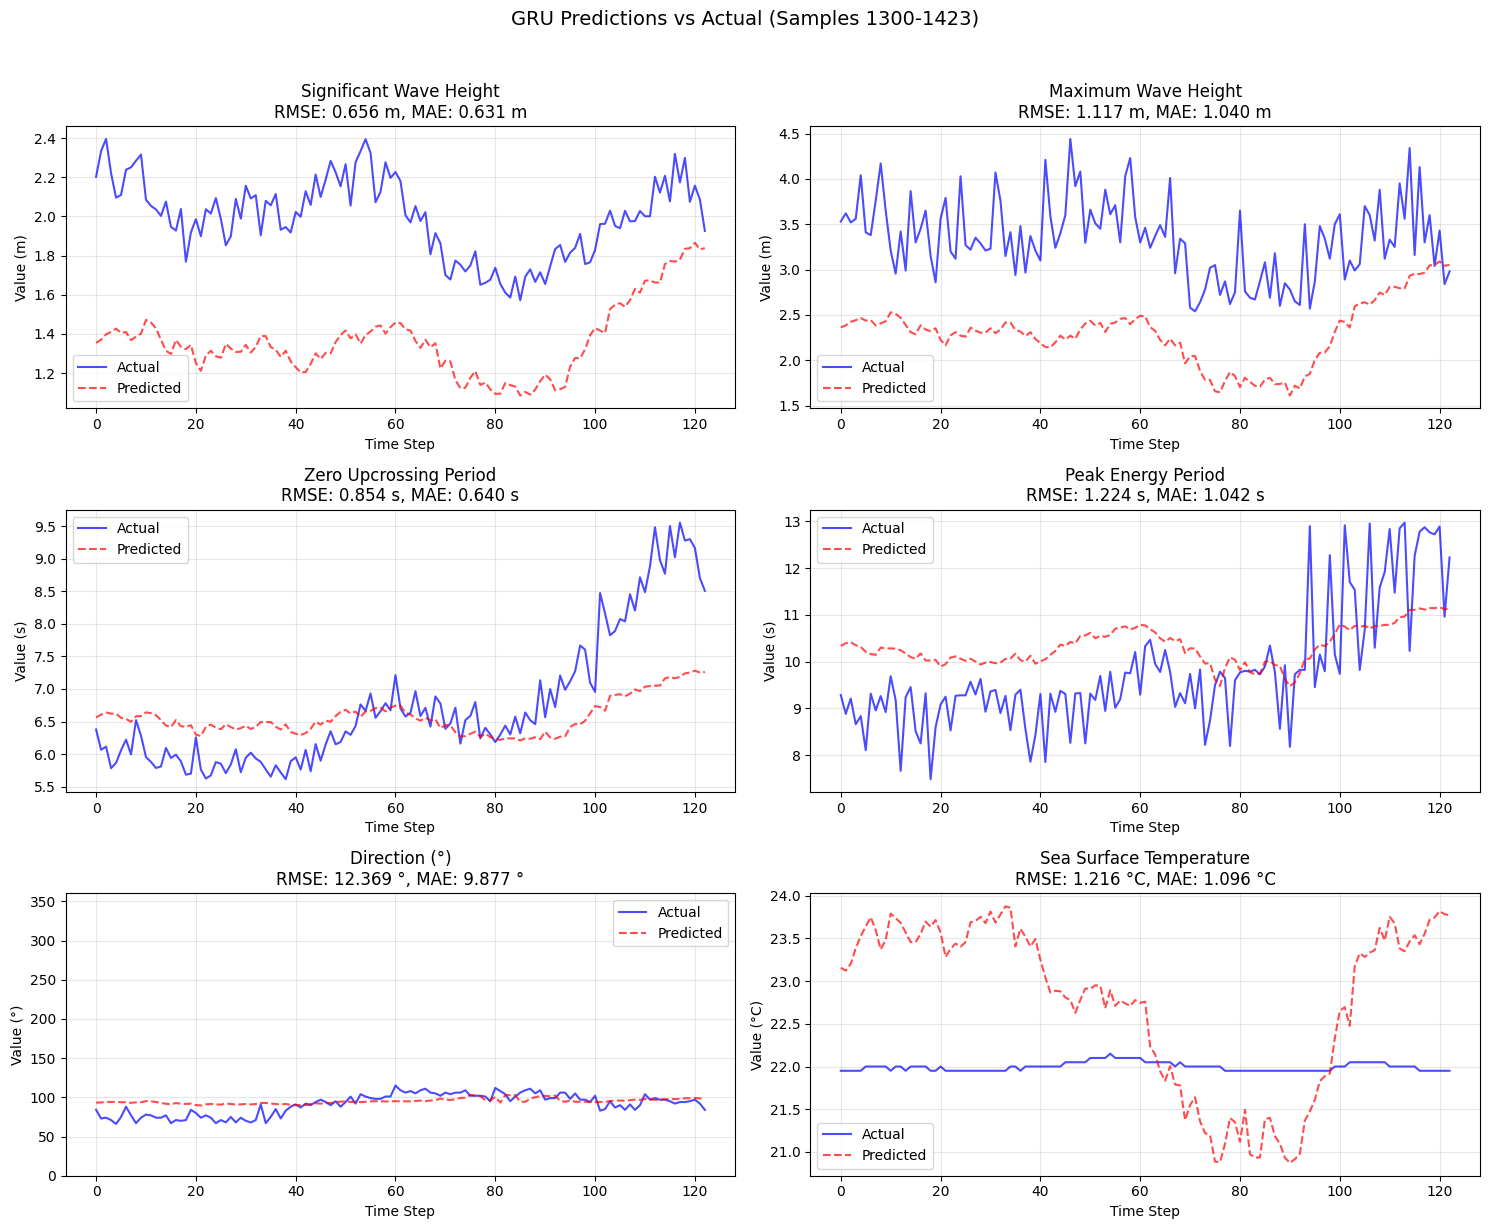

In [25]:
import matplotlib.pyplot as plt

def plot_gru_results(y_true, y_pred, start_idx=1300, end_idx=1423):
    """
    Plot GRU predictions vs actual values
    """
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.flatten()

    feature_names = ['Significant Wave Height', 'Maximum Wave Height',
                     'Zero Upcrossing Period', 'Peak Energy Period',
                     'Direction (°)', 'Sea Surface Temperature']
    units = ['m', 'm', 's', 's', '°', '°C']

    for i in range(6):
        ax = axes[i]

        # Get data slice
        real_data = y_true[start_idx:end_idx, i]
        pred_data = y_pred[start_idx:end_idx, i]

        # Plot
        ax.plot(real_data, label='Actual', color='blue', alpha=0.7, linewidth=1.5)
        ax.plot(pred_data, label='Predicted', color='red', alpha=0.7, linewidth=1.5, linestyle='--')

        # Calculate metrics
        rmse = math.sqrt(mean_squared_error(real_data, pred_data))
        mae = mean_absolute_error(real_data, pred_data)

        # Set title and labels
        ax.set_title(f'{feature_names[i]}\nRMSE: {rmse:.3f} {units[i]}, MAE: {mae:.3f} {units[i]}')
        ax.set_xlabel('Time Step')
        ax.set_ylabel(f'Value ({units[i]})')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Special handling for direction
        if i == 4:  # Direction
            ax.set_ylim([0, 360])

    plt.suptitle(f'GRU Predictions vs Actual (Samples {start_idx}-{end_idx})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Plot results
plot_gru_results(test_actual_final, test_pred_final)

# Temporal Fusion Transformer (TFT) - Multi-Target Implementation

Proper TFT architecture with:
- Variable Selection Networks (VSN)
- Gated Residual Networks (GRN)  
- Multi-head Attention
- Predicts all 6 ocean wave features

In [26]:
# =============================================================================
# TEMPORAL FUSION TRANSFORMER (TFT) - CORE COMPONENTS
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class GatedLinearUnit(nn.Module):
    """Gated Linear Unit for controlling information flow"""
    def __init__(self, input_size, hidden_size, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        sig = torch.sigmoid(self.fc1(x))
        x = self.dropout(self.fc2(x))
        return sig * x

class GatedResidualNetwork(nn.Module):
    """
    Gated Residual Network (GRN) - Key TFT component
    Provides flexible nonlinear processing with skip connections
    """
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1, context_size=None):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.context_size = context_size

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

        if context_size is not None:
            self.context_fc = nn.Linear(context_size, hidden_size, bias=False)

        self.gate = nn.Linear(output_size, output_size)
        self.layer_norm = nn.LayerNorm(output_size)

        if input_size != output_size:
            self.skip_layer = nn.Linear(input_size, output_size)
        else:
            self.skip_layer = None

    def forward(self, x, context=None):
        # Skip connection
        if self.skip_layer is not None:
            skip = self.skip_layer(x)
        else:
            skip = x

        # Main pathway
        hidden = self.fc1(x)
        if context is not None and self.context_size is not None:
            hidden = hidden + self.context_fc(context)
        hidden = self.elu(hidden)
        hidden = self.fc2(hidden)
        hidden = self.dropout(hidden)

        # Gating
        gating = torch.sigmoid(self.gate(hidden))
        output = gating * hidden

        # Add & Norm
        output = self.layer_norm(output + skip)
        return output

class VariableSelectionNetwork(nn.Module):
    """
    Variable Selection Network (VSN)
    Learns to select relevant input variables
    """
    def __init__(self, input_size, num_inputs, hidden_size, dropout=0.1, context_size=None):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_inputs = num_inputs
        self.input_size = input_size

        # GRN for each input variable
        self.input_grns = nn.ModuleList([
            GatedResidualNetwork(input_size, hidden_size, hidden_size, dropout)
            for _ in range(num_inputs)
        ])

        # GRN for variable selection weights
        self.selection_grn = GatedResidualNetwork(
            input_size * num_inputs, hidden_size, num_inputs, dropout, context_size
        )

    def forward(self, inputs, context=None):
        # inputs: (batch, num_inputs, input_size)
        batch_size = inputs.size(0)

        # Process each variable
        processed = []
        for i, grn in enumerate(self.input_grns):
            processed.append(grn(inputs[:, i, :]))
        processed = torch.stack(processed, dim=1)  # (batch, num_inputs, hidden_size)

        # Calculate selection weights
        flattened = inputs.reshape(batch_size, -1)
        weights = self.selection_grn(flattened, context)
        weights = F.softmax(weights, dim=-1).unsqueeze(-1)  # (batch, num_inputs, 1)

        # Weighted sum
        output = (processed * weights).sum(dim=1)  # (batch, hidden_size)
        return output, weights

class InterpretableMultiHeadAttention(nn.Module):
    """
    Interpretable Multi-Head Attention
    Modified attention that shares values across heads for interpretability
    """
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_size = hidden_size // num_heads

        self.q_linear = nn.Linear(hidden_size, hidden_size)
        self.k_linear = nn.Linear(hidden_size, hidden_size)
        self.v_linear = nn.Linear(hidden_size, hidden_size)
        self.out_linear = nn.Linear(hidden_size, hidden_size)

        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_size ** -0.5

    def forward(self, query, key, value, mask=None):
        batch_size, seq_len, _ = query.size()

        # Linear projections
        Q = self.q_linear(query).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        K = self.k_linear(key).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        V = self.v_linear(value).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Apply attention to values
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.hidden_size)

        output = self.out_linear(context)
        return output, attn_weights

print("TFT Core Components Defined:")
print("✓ Gated Linear Unit (GLU)")
print("✓ Gated Residual Network (GRN)")
print("✓ Variable Selection Network (VSN)")
print("✓ Interpretable Multi-Head Attention")

TFT Core Components Defined:
✓ Gated Linear Unit (GLU)
✓ Gated Residual Network (GRN)
✓ Variable Selection Network (VSN)
✓ Interpretable Multi-Head Attention


In [27]:
# =============================================================================
# TEMPORAL FUSION TRANSFORMER - FULL MODEL
# =============================================================================

class TemporalFusionTransformerMultiTarget(nn.Module):
    """
    Temporal Fusion Transformer for Multi-Target Time Series Prediction

    Architecture:
    1. Variable Selection Networks for input processing
    2. LSTM Encoder for temporal patterns
    3. Static Enrichment with GRN
    4. Temporal Self-Attention
    5. Position-wise Feed-forward
    6. Multi-target output
    """
    def __init__(self, n_features=6, n_timesteps=30, hidden_size=64,
                 num_heads=4, num_lstm_layers=2, dropout=0.1):
        super().__init__()

        self.n_features = n_features
        self.n_timesteps = n_timesteps
        self.hidden_size = hidden_size

        # Input embedding for each feature
        self.input_embeddings = nn.ModuleList([
            nn.Linear(1, hidden_size) for _ in range(n_features)
        ])

        # Variable Selection Network
        self.vsn = VariableSelectionNetwork(
            input_size=hidden_size,
            num_inputs=n_features,
            hidden_size=hidden_size,
            dropout=dropout
        )

        # LSTM Encoder for temporal processing
        self.lstm_encoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_lstm_layers,
            dropout=dropout if num_lstm_layers > 1 else 0,
            batch_first=True
        )

        # Static context GRN
        self.static_context_grn = GatedResidualNetwork(
            hidden_size, hidden_size, hidden_size, dropout
        )

        # Temporal Self-Attention
        self.self_attention = InterpretableMultiHeadAttention(
            hidden_size, num_heads, dropout
        )
        self.attention_grn = GatedResidualNetwork(
            hidden_size, hidden_size, hidden_size, dropout
        )

        # Position-wise Feed-forward
        self.ff_grn = GatedResidualNetwork(
            hidden_size, hidden_size * 4, hidden_size, dropout
        )

        # Output layers
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_features)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (batch, features, timesteps) - same format as LSTM/GRU
        """
        batch_size = x.size(0)

        # Reshape to (batch, timesteps, features)
        x = x.permute(0, 2, 1)  # (batch, timesteps, features)

        # Embed each feature
        embedded_inputs = []
        for t in range(self.n_timesteps):
            timestep_embeddings = []
            for f in range(self.n_features):
                feat_input = x[:, t, f:f+1]  # (batch, 1)
                embedded = self.input_embeddings[f](feat_input)  # (batch, hidden_size)
                timestep_embeddings.append(embedded)
            timestep_embeddings = torch.stack(timestep_embeddings, dim=1)  # (batch, n_features, hidden_size)
            embedded_inputs.append(timestep_embeddings)

        # Process through Variable Selection Network for each timestep
        vsn_outputs = []
        for t in range(self.n_timesteps):
            vsn_out, _ = self.vsn(embedded_inputs[t])  # (batch, hidden_size)
            vsn_outputs.append(vsn_out)
        vsn_outputs = torch.stack(vsn_outputs, dim=1)  # (batch, timesteps, hidden_size)

        # LSTM encoding
        lstm_out, (hidden, cell) = self.lstm_encoder(vsn_outputs)
        # lstm_out: (batch, timesteps, hidden_size)

        # Static context from final hidden state
        static_context = self.static_context_grn(hidden[-1])  # (batch, hidden_size)

        # Temporal Self-Attention
        attn_out, attn_weights = self.self_attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.attention_grn(attn_out[:, -1, :])  # Use last timestep

        # Add static context
        combined = attn_out + static_context

        # Feed-forward
        ff_out = self.ff_grn(combined)

        # Output prediction for all features
        output = self.output_layer(ff_out)  # (batch, n_features)

        return output

# Define these variables globally for the print statements
n_features = 6
n_timesteps = 30

print("\n" + "="*60)
print("TEMPORAL FUSION TRANSFORMER MODEL DEFINED")
print("="*60)
print(f"Architecture:")
print(f"  - Input: ({n_features} features × {n_timesteps} timesteps)")
print(f"  - Variable Selection Networks")
print(f"  - LSTM Encoder (2 layers)")
print(f"  - Multi-Head Self-Attention (4 heads)")
print(f"  - Gated Residual Networks")
print(f"  - Output: {n_features} features")


TEMPORAL FUSION TRANSFORMER MODEL DEFINED
Architecture:
  - Input: (6 features × 30 timesteps)
  - Variable Selection Networks
  - LSTM Encoder (2 layers)
  - Multi-Head Self-Attention (4 heads)
  - Gated Residual Networks
  - Output: 6 features


In [28]:
# =============================================================================
# TFT DATA PREPARATION (Same format as LSTM)
# =============================================================================

# Use the same scaled data as LSTM
def prepare_data_tft(data, databatch=30):
    """Same data preparation as LSTM for fair comparison"""
    x_list = []
    y_list = []

    for i in range(len(data) - databatch - 1):
        x_list.append(data[i:i + databatch])
        y_list.append(data[i + databatch + 1])

    X_data = np.array(x_list)
    # Reshape to (samples, features, timesteps) - same as LSTM
    X_data = np.reshape(X_data, (X_data.shape[0], X_data.shape[2], X_data.shape[1]))
    y_data = np.array(y_list)

    return X_data, y_data

# Prepare data using 'train' and 'test' from earlier cells
X_train_tft, y_train_tft = prepare_data_tft(train)
X_test_tft, y_test_tft = prepare_data_tft(test)

print("TFT Data Shapes (Same as LSTM):")
print(f"X_train: {X_train_tft.shape}, y_train: {y_train_tft.shape}")
print(f"X_test:  {X_test_tft.shape},  y_test:  {y_test_tft.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_tft)
y_train_tensor = torch.FloatTensor(y_train_tft)
X_test_tensor = torch.FloatTensor(X_test_tft)
y_test_tensor = torch.FloatTensor(y_test_tft)

# Create DataLoaders
batch_size = 200  # Same as LSTM
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)  # For validation
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created with batch_size={batch_size}")

TFT Data Shapes (Same as LSTM):
X_train: (41969, 6, 30), y_train: (41969, 6)
X_test:  (1423, 6, 30),  y_test:  (1423, 6)

DataLoaders created with batch_size=200


In [29]:
# =============================================================================
# TFT MODEL TRAINING
# =============================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Model parameters
n_features = X_train_tft.shape[1]  # 6
n_timesteps = X_train_tft.shape[2]  # 30

# Initialize TFT model
tft_model = TemporalFusionTransformerMultiTarget(
    n_features=n_features,
    n_timesteps=n_timesteps,
    hidden_size=64,
    num_heads=4,
    num_lstm_layers=2,
    dropout=0.2
).to(device)

# Count parameters
total_params = sum(p.numel() for p in tft_model.parameters())
print(f"Total TFT Parameters: {total_params:,}")

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(tft_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Training settings
num_epochs = 50  # Same as original TFT
best_val_loss = float('inf')
patience = 10
patience_counter = 0
train_losses = []
val_losses = []

print("\n" + "="*60)
print("TRAINING TFT MODEL")
print("="*60)

for epoch in range(num_epochs):
    # Training phase
    tft_model.train()
    epoch_train_loss = 0
    num_batches = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = tft_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(tft_model.parameters(), 1.0)
        optimizer.step()

        epoch_train_loss += loss.item()
        num_batches += 1

    avg_train_loss = epoch_train_loss / num_batches
    train_losses.append(avg_train_loss)

    # Validation phase (using test set as validation for simplicity)
    tft_model.eval()
    epoch_val_loss = 0
    num_val_batches = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = tft_model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_val_loss += loss.item()
            num_val_batches += 1

    avg_val_loss = epoch_val_loss / num_val_batches
    val_losses.append(avg_val_loss)

    # Learning rate scheduling
    scheduler.step(avg_val_loss)

    # Print progress
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(tft_model.state_dict(), 'best_tft_multi_target.pth')
        print(f"  ✓ Best model saved (Val Loss: {best_val_loss:.6f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠ Early stopping at epoch {epoch+1}")
            break

print("\n" + "="*60)
print("TRAINING COMPLETE")
print(f"Best Validation Loss: {best_val_loss:.6f}")
print("="*60)

# Load best model
tft_model.load_state_dict(torch.load('best_tft_multi_target.pth'))
print("✓ Best model loaded")

Using device: cpu
Total TFT Parameters: 254,152

TRAINING TFT MODEL
Epoch 01/50 | Train Loss: 0.020834 | Val Loss: 0.009653
  ✓ Best model saved (Val Loss: 0.009653)
Epoch 02/50 | Train Loss: 0.007908 | Val Loss: 0.005915
  ✓ Best model saved (Val Loss: 0.005915)
Epoch 03/50 | Train Loss: 0.005772 | Val Loss: 0.005289
  ✓ Best model saved (Val Loss: 0.005289)
Epoch 04/50 | Train Loss: 0.004856 | Val Loss: 0.003966
  ✓ Best model saved (Val Loss: 0.003966)
Epoch 05/50 | Train Loss: 0.004286 | Val Loss: 0.003736
  ✓ Best model saved (Val Loss: 0.003736)
Epoch 06/50 | Train Loss: 0.003880 | Val Loss: 0.003427
  ✓ Best model saved (Val Loss: 0.003427)
Epoch 07/50 | Train Loss: 0.003609 | Val Loss: 0.003129
  ✓ Best model saved (Val Loss: 0.003129)
Epoch 08/50 | Train Loss: 0.003442 | Val Loss: 0.003190
Epoch 09/50 | Train Loss: 0.003316 | Val Loss: 0.002957
  ✓ Best model saved (Val Loss: 0.002957)
Epoch 10/50 | Train Loss: 0.003271 | Val Loss: 0.003212
Epoch 11/50 | Train Loss: 0.003201 |

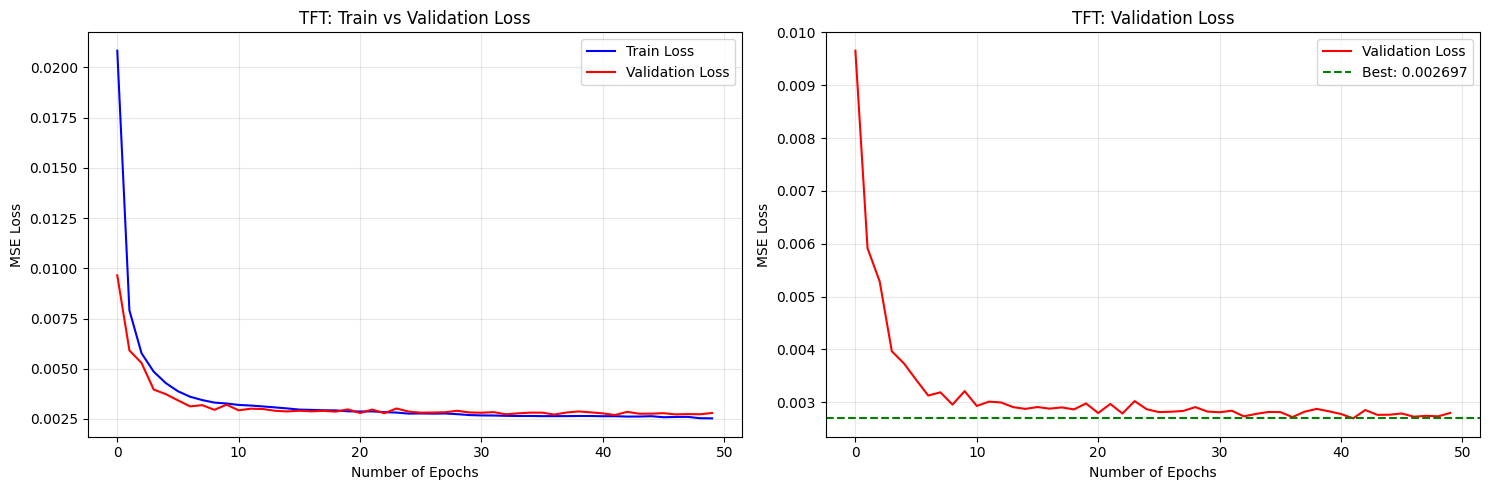

In [30]:
# =============================================================================
# TFT: VISUALIZATION OF LEARNING
# =============================================================================

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, color='blue', label='Train Loss')
plt.plot(val_losses, color='red', label='Validation Loss')
plt.title('TFT: Train vs Validation Loss')
plt.xlabel('Number of Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_losses, color='red', label='Validation Loss')
plt.axhline(y=best_val_loss, color='green', linestyle='--', label=f'Best: {best_val_loss:.6f}')
plt.title('TFT: Validation Loss')
plt.xlabel('Number of Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## TFT Predictions

In [31]:
# =============================================================================
# TFT PREDICTIONS
# =============================================================================

tft_model.eval()

# Get predictions on test set
with torch.no_grad():
    tft_pred_scaled = tft_model(X_test_tensor.to(device)).cpu().numpy()

# Inverse transform to original scale
tft_prediction = scaler.inverse_transform(tft_pred_scaled)
y_test_tft_original = scaler.inverse_transform(y_test_tft)

print(f"TFT Predictions shape: {tft_prediction.shape}")
print(f"TFT Actual values shape: {y_test_tft_original.shape}")

TFT Predictions shape: (1423, 6)
TFT Actual values shape: (1423, 6)


## TFT: Evaluating Model Success

In [32]:
# =============================================================================
# TFT: RMSE EVALUATION (Same format as LSTM)
# =============================================================================

print("TFT Test Data Errors")
print("-" * 40)
examine_rmse(y_test_tft_original, tft_prediction)

TFT Test Data Errors
----------------------------------------
RMSE_Hs       :  0.08429065756464128
RMSE_Hmax     :  0.24041718063259485
RMSE_Tz       :  0.33131252563605323
RMSE_Tp       :  1.9400286505908053
RMSE_Direction:  13.88180996193169
RMSE_SST      :  0.11245781902447488


## TFT: Visualization of Real and Predicted Values

Same visualization style as LSTM (samples 1300+)

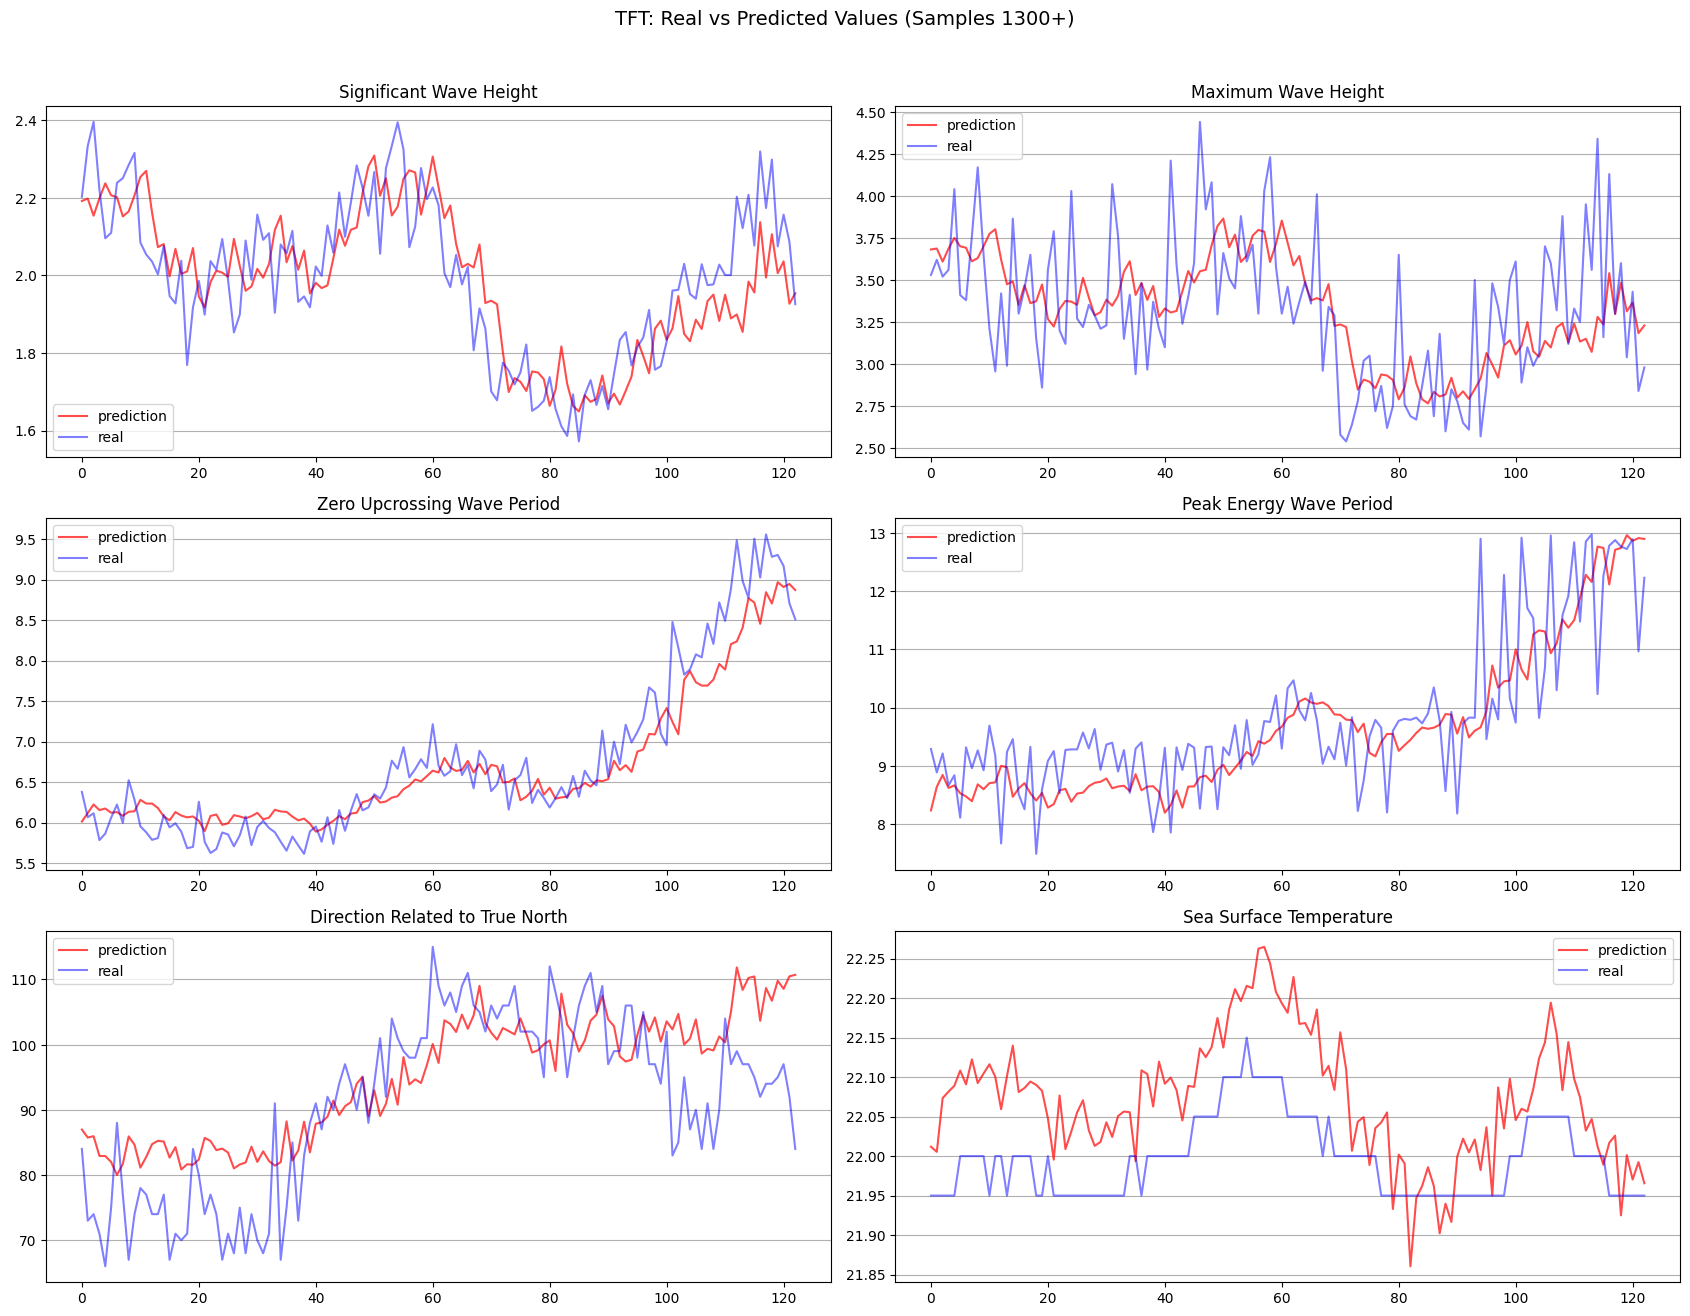

In [33]:
# =============================================================================
# TFT: VISUALIZATION (SAME FORMAT AS LSTM)
# =============================================================================

plt.figure(figsize=(17, 25))

plt.subplot(6, 2, 1)
plt.plot(tft_prediction[1300:, 0], color='red', alpha=0.7, label='prediction')
plt.plot(y_test_tft_original[1300:, 0], color='blue', alpha=0.5, label='real')
plt.title('Significant Wave Height')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6, 2, 2)
plt.plot(tft_prediction[1300:, 1], color='red', alpha=0.7, label='prediction')
plt.plot(y_test_tft_original[1300:, 1], color='blue', alpha=0.5, label='real')
plt.title('Maximum Wave Height')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6, 2, 3)
plt.plot(tft_prediction[1300:, 2], color='red', alpha=0.7, label='prediction')
plt.plot(y_test_tft_original[1300:, 2], color='blue', alpha=0.5, label='real')
plt.title('Zero Upcrossing Wave Period')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6, 2, 4)
plt.plot(tft_prediction[1300:, 3], color='red', alpha=0.7, label='prediction')
plt.plot(y_test_tft_original[1300:, 3], color='blue', alpha=0.5, label='real')
plt.title('Peak Energy Wave Period')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6, 2, 5)
plt.plot(tft_prediction[1300:, 4], color='red', alpha=0.7, label='prediction')
plt.plot(y_test_tft_original[1300:, 4], color='blue', alpha=0.5, label='real')
plt.title('Direction Related to True North')
plt.legend()
plt.grid(True, axis='y')

plt.subplot(6, 2, 6)
plt.plot(tft_prediction[1300:, 5], color='red', alpha=0.7, label='prediction')
plt.plot(y_test_tft_original[1300:, 5], color='blue', alpha=0.5, label='real')
plt.title('Sea Surface Temperature')
plt.legend()
plt.grid(True, axis='y')

plt.suptitle('TFT: Real vs Predicted Values (Samples 1300+)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Model Comparison: LSTM vs GRU vs TFT

Comparing all three models on the same test data with identical evaluation metrics.

In [34]:
# =============================================================================
# MODEL COMPARISON: LSTM vs GRU vs TFT
# =============================================================================

import math
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_metrics(y_true, y_pred):
    """Calculate RMSE, MAE, MAPE, and R² for each feature"""
    feature_names = ['Hs', 'Hmax', 'Tz', 'Tp', 'Direction', 'SST']
    metrics = {}

    for i, feat in enumerate(feature_names):
        rmse = math.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        # Avoid division by zero in MAPE
        mask = y_true[:, i] != 0
        mape = np.mean(np.abs((y_true[:, i][mask] - y_pred[:, i][mask]) / y_true[:, i][mask])) * 100
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        metrics[feat] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

    # Overall metrics
    overall_rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    overall_mae = mean_absolute_error(y_true, y_pred)
    mask_all = y_true.flatten() != 0
    overall_mape = np.mean(np.abs((y_true.flatten()[mask_all] - y_pred.flatten()[mask_all]) / y_true.flatten()[mask_all])) * 100
    overall_r2 = r2_score(y_true.flatten(), y_pred.flatten())
    metrics['Overall'] = {'RMSE': overall_rmse, 'MAE': overall_mae, 'MAPE': overall_mape, 'R2': overall_r2}

    return metrics

# Calculate metrics for each model
# LSTM: test_prediction, y_test
# GRU: test_pred_final, test_actual_final
# TFT: tft_prediction, y_test_tft_original

lstm_metrics = calculate_metrics(y_test, test_prediction)
gru_metrics = calculate_metrics(test_actual_final, test_pred_final)
tft_metrics = calculate_metrics(y_test_tft_original, tft_prediction)

# =============================================================================
# COMPARISON TABLE
# =============================================================================
print("="*90)
print("MODEL COMPARISON: RMSE (Root Mean Squared Error)")
print("="*90)
print(f"{'Feature':<15} {'LSTM':<15} {'GRU':<15} {'TFT':<15} {'Best Model':<15}")
print("-"*90)

feature_names = ['Hs', 'Hmax', 'Tz', 'Tp', 'Direction', 'SST', 'Overall']
for feat in feature_names:
    lstm_val = lstm_metrics[feat]['RMSE']
    gru_val = gru_metrics[feat]['RMSE']
    tft_val = tft_metrics[feat]['RMSE']

    # Find best (lowest RMSE)
    best = min(lstm_val, gru_val, tft_val)
    if best == lstm_val:
        best_model = "LSTM ✓"
    elif best == gru_val:
        best_model = "GRU ✓"
    else:
        best_model = "TFT ✓"

    if feat == 'Overall':
        print("-"*90)
    print(f"{feat:<15} {lstm_val:<15.4f} {gru_val:<15.4f} {tft_val:<15.4f} {best_model:<15}")

print("="*90)

# =============================================================================
# MAE COMPARISON
# =============================================================================
print("\n" + "="*90)
print("MODEL COMPARISON: MAE (Mean Absolute Error)")
print("="*90)
print(f"{'Feature':<15} {'LSTM':<15} {'GRU':<15} {'TFT':<15} {'Best Model':<15}")
print("-"*90)

for feat in feature_names:
    lstm_val = lstm_metrics[feat]['MAE']
    gru_val = gru_metrics[feat]['MAE']
    tft_val = tft_metrics[feat]['MAE']

    best = min(lstm_val, gru_val, tft_val)
    if best == lstm_val:
        best_model = "LSTM ✓"
    elif best == gru_val:
        best_model = "GRU ✓"
    else:
        best_model = "TFT ✓"

    if feat == 'Overall':
        print("-"*90)
    print(f"{feat:<15} {lstm_val:<15.4f} {gru_val:<15.4f} {tft_val:<15.4f} {best_model:<15}")

print("="*90)

# =============================================================================
# MAPE COMPARISON
# =============================================================================
print("\n" + "="*90)
print("MODEL COMPARISON: MAPE (Mean Absolute Percentage Error) — Lower is Better (%)")
print("="*90)
print(f"{'Feature':<15} {'LSTM':<15} {'GRU':<15} {'TFT':<15} {'Best Model':<15}")
print("-"*90)

for feat in feature_names:
    lstm_val = lstm_metrics[feat]['MAPE']
    gru_val = gru_metrics[feat]['MAPE']
    tft_val = tft_metrics[feat]['MAPE']

    best = min(lstm_val, gru_val, tft_val)
    if best == lstm_val:
        best_model = "LSTM ✓"
    elif best == gru_val:
        best_model = "GRU ✓"
    else:
        best_model = "TFT ✓"

    if feat == 'Overall':
        print("-"*90)
    print(f"{feat:<15} {lstm_val:<15.4f} {gru_val:<15.4f} {tft_val:<15.4f} {best_model:<15}")

print("="*90)

# =============================================================================
# R² COMPARISON
# =============================================================================
print("\n" + "="*90)
print("MODEL COMPARISON: R² Score (Higher is Better)")
print("="*90)
print(f"{'Feature':<15} {'LSTM':<15} {'GRU':<15} {'TFT':<15} {'Best Model':<15}")
print("-"*90)

for feat in feature_names:
    lstm_val = lstm_metrics[feat]['R2']
    gru_val = gru_metrics[feat]['R2']
    tft_val = tft_metrics[feat]['R2']

    # For R², higher is better
    best = max(lstm_val, gru_val, tft_val)
    if best == lstm_val:
        best_model = "LSTM ✓"
    elif best == gru_val:
        best_model = "GRU ✓"
    else:
        best_model = "TFT ✓"

    if feat == 'Overall':
        print("-"*90)
    print(f"{feat:<15} {lstm_val:<15.4f} {gru_val:<15.4f} {tft_val:<15.4f} {best_model:<15}")

print("="*90)

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*90)
print("FINAL SUMMARY")
print("="*90)

# Count wins for each model
lstm_wins = sum(1 for feat in feature_names[:-1] if lstm_metrics[feat]['RMSE'] == min(lstm_metrics[feat]['RMSE'], gru_metrics[feat]['RMSE'], tft_metrics[feat]['RMSE']))
gru_wins = sum(1 for feat in feature_names[:-1] if gru_metrics[feat]['RMSE'] == min(lstm_metrics[feat]['RMSE'], gru_metrics[feat]['RMSE'], tft_metrics[feat]['RMSE']))
tft_wins = sum(1 for feat in feature_names[:-1] if tft_metrics[feat]['RMSE'] == min(lstm_metrics[feat]['RMSE'], gru_metrics[feat]['RMSE'], tft_metrics[feat]['RMSE']))

print(f"Features won (by RMSE): LSTM={lstm_wins}, GRU={gru_wins}, TFT={tft_wins}")
print(f"\nOverall RMSE:  LSTM={lstm_metrics['Overall']['RMSE']:.4f}, GRU={gru_metrics['Overall']['RMSE']:.4f}, TFT={tft_metrics['Overall']['RMSE']:.4f}")
print(f"Overall MAE:   LSTM={lstm_metrics['Overall']['MAE']:.4f}, GRU={gru_metrics['Overall']['MAE']:.4f}, TFT={tft_metrics['Overall']['MAE']:.4f}")
print(f"Overall MAPE:  LSTM={lstm_metrics['Overall']['MAPE']:.4f}%, GRU={gru_metrics['Overall']['MAPE']:.4f}%, TFT={tft_metrics['Overall']['MAPE']:.4f}%")
print(f"Overall R²:    LSTM={lstm_metrics['Overall']['R2']:.4f}, GRU={gru_metrics['Overall']['R2']:.4f}, TFT={tft_metrics['Overall']['R2']:.4f}")

# Determine overall best model
overall_rmse_vals = {'LSTM': lstm_metrics['Overall']['RMSE'],
                     'GRU': gru_metrics['Overall']['RMSE'],
                     'TFT': tft_metrics['Overall']['RMSE']}
best_overall = min(overall_rmse_vals, key=overall_rmse_vals.get)
print(f"\n🏆 Best Overall Model (by RMSE): {best_overall}")
print("="*90)

MODEL COMPARISON: RMSE (Root Mean Squared Error)
Feature         LSTM            GRU             TFT             Best Model     
------------------------------------------------------------------------------------------
Hs              0.0886          0.4260          0.0843          TFT ✓          
Hmax            0.2438          0.7838          0.2404          TFT ✓          
Tz              0.3426          0.7110          0.3313          TFT ✓          
Tp              1.9579          2.5560          1.9400          TFT ✓          
Direction       14.4912         16.6313         13.8818         TFT ✓          
SST             0.2030          0.8611          0.1125          TFT ✓          
------------------------------------------------------------------------------------------
Overall         5.9729          6.8941          5.7250          TFT ✓          

MODEL COMPARISON: MAE (Mean Absolute Error)
Feature         LSTM            GRU             TFT             Best Model     
----

## Time-Series Cross-Validation (Rolling Folds)

This section evaluates LSTM, GRU, and TFT using `TimeSeriesSplit` on each model's prediction timeline.

Why this helps:
- Preserves temporal order (no leakage from future to past)
- Measures performance stability across multiple time windows
- Reports mean ± std across folds for a stronger comparison than a single split

In [35]:
from sklearn.model_selection import TimeSeriesSplit

# =============================================================================
# TIME-SERIES CROSS-VALIDATION FOR MODEL COMPARISON
# =============================================================================

def overall_metrics_cv(y_true, y_pred):
    """Compute overall metrics on a fold."""
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    mask = y_true.flatten() != 0
    if np.any(mask):
        mape = np.mean(np.abs((y_true.flatten()[mask] - y_pred.flatten()[mask]) / y_true.flatten()[mask])) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true.flatten(), y_pred.flatten())
    return rmse, mae, mape, r2


def run_time_series_cv(y_true, y_pred, n_splits=5):
    """Run rolling-origin CV on aligned prediction timelines."""
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rows = []

    for fold, (_, test_idx) in enumerate(tscv.split(np.arange(n)), start=1):
        y_fold = y_true[test_idx]
        p_fold = y_pred[test_idx]
        rmse, mae, mape, r2 = overall_metrics_cv(y_fold, p_fold)
        fold_rows.append({
            'Fold': fold,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'R2': r2,
            'Samples': len(test_idx)
        })

    return pd.DataFrame(fold_rows)


# Build CV tables for each model
cv_lstm = run_time_series_cv(y_test, test_prediction, n_splits=5)
cv_gru = run_time_series_cv(test_actual_final, test_pred_final, n_splits=5)
cv_tft = run_time_series_cv(y_test_tft_original, tft_prediction, n_splits=5)

# Print fold-by-fold results
print('=' * 100)
print('TIME-SERIES CROSS-VALIDATION RESULTS (5 Rolling Folds)')
print('=' * 100)

for model_name, df_cv in [('LSTM', cv_lstm), ('GRU', cv_gru), ('TFT', cv_tft)]:
    print(f"\n{model_name} - Fold Metrics")
    print('-' * 100)
    print(df_cv.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# Summary table: mean ± std across folds
summary_rows = []
for model_name, df_cv in [('LSTM', cv_lstm), ('GRU', cv_gru), ('TFT', cv_tft)]:
    summary_rows.append({
        'Model': model_name,
        'RMSE_mean': df_cv['RMSE'].mean(),
        'RMSE_std': df_cv['RMSE'].std(ddof=1),
        'MAE_mean': df_cv['MAE'].mean(),
        'MAE_std': df_cv['MAE'].std(ddof=1),
        'MAPE_mean': df_cv['MAPE'].mean(),
        'MAPE_std': df_cv['MAPE'].std(ddof=1),
        'R2_mean': df_cv['R2'].mean(),
        'R2_std': df_cv['R2'].std(ddof=1)
    })

cv_summary = pd.DataFrame(summary_rows)

print('\n' + '=' * 100)
print('CROSS-VALIDATION SUMMARY (mean ± std across folds)')
print('=' * 100)
for _, row in cv_summary.iterrows():
    print(
        f"{row['Model']:<5} | "
        f"RMSE: {row['RMSE_mean']:.4f} ± {row['RMSE_std']:.4f} | "
        f"MAE: {row['MAE_mean']:.4f} ± {row['MAE_std']:.4f} | "
        f"MAPE: {row['MAPE_mean']:.4f}% ± {row['MAPE_std']:.4f}% | "
        f"R2: {row['R2_mean']:.4f} ± {row['R2_std']:.4f}"
    )

best_cv_model = cv_summary.loc[cv_summary['RMSE_mean'].idxmin(), 'Model']
print('\n' + '=' * 100)
print(f"Best Model by CV RMSE (mean across folds): {best_cv_model}")
print('=' * 100)

# Optional compact table for display
cv_summary

TIME-SERIES CROSS-VALIDATION RESULTS (5 Rolling Folds)

LSTM - Fold Metrics
----------------------------------------------------------------------------------------------------
 Fold   RMSE    MAE    MAPE     R2  Samples
    1 4.9284 1.9315  7.6464 0.9843      237
    2 7.1044 2.4943  9.2085 0.9667      237
    3 8.6213 2.4179 11.1458 0.9535      237
    4 4.2592 1.5524  7.0185 0.9898      237
    5 3.4362 1.3493  5.3354 0.9884      237

GRU - Fold Metrics
----------------------------------------------------------------------------------------------------
 Fold   RMSE    MAE    MAPE     R2  Samples
    1 4.7227 2.1198 17.7841 0.9856      237
    2 8.0192 3.4720 19.5813 0.9576      237
    3 9.3914 3.5374 24.3816 0.9449      237
    4 5.1346 2.2353 14.8901 0.9852      237
    5 4.9037 2.4694 19.5330 0.9764      237

TFT - Fold Metrics
----------------------------------------------------------------------------------------------------
 Fold   RMSE    MAE    MAPE     R2  Samples
    1 4.7

,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,R2_mean,R2_std
0,LSTM,5.669899,2.138779,1.949099,0.508542,8.070907,2.209051,0.976551,0.015823
1,GRU,6.434316,2.134118,2.766770,0.685672,19.234050,3.452519,0.969918,0.018014
2,TFT,5.399267,2.016208,1.806295,0.482733,7.832345,1.940148,0.978575,0.013986


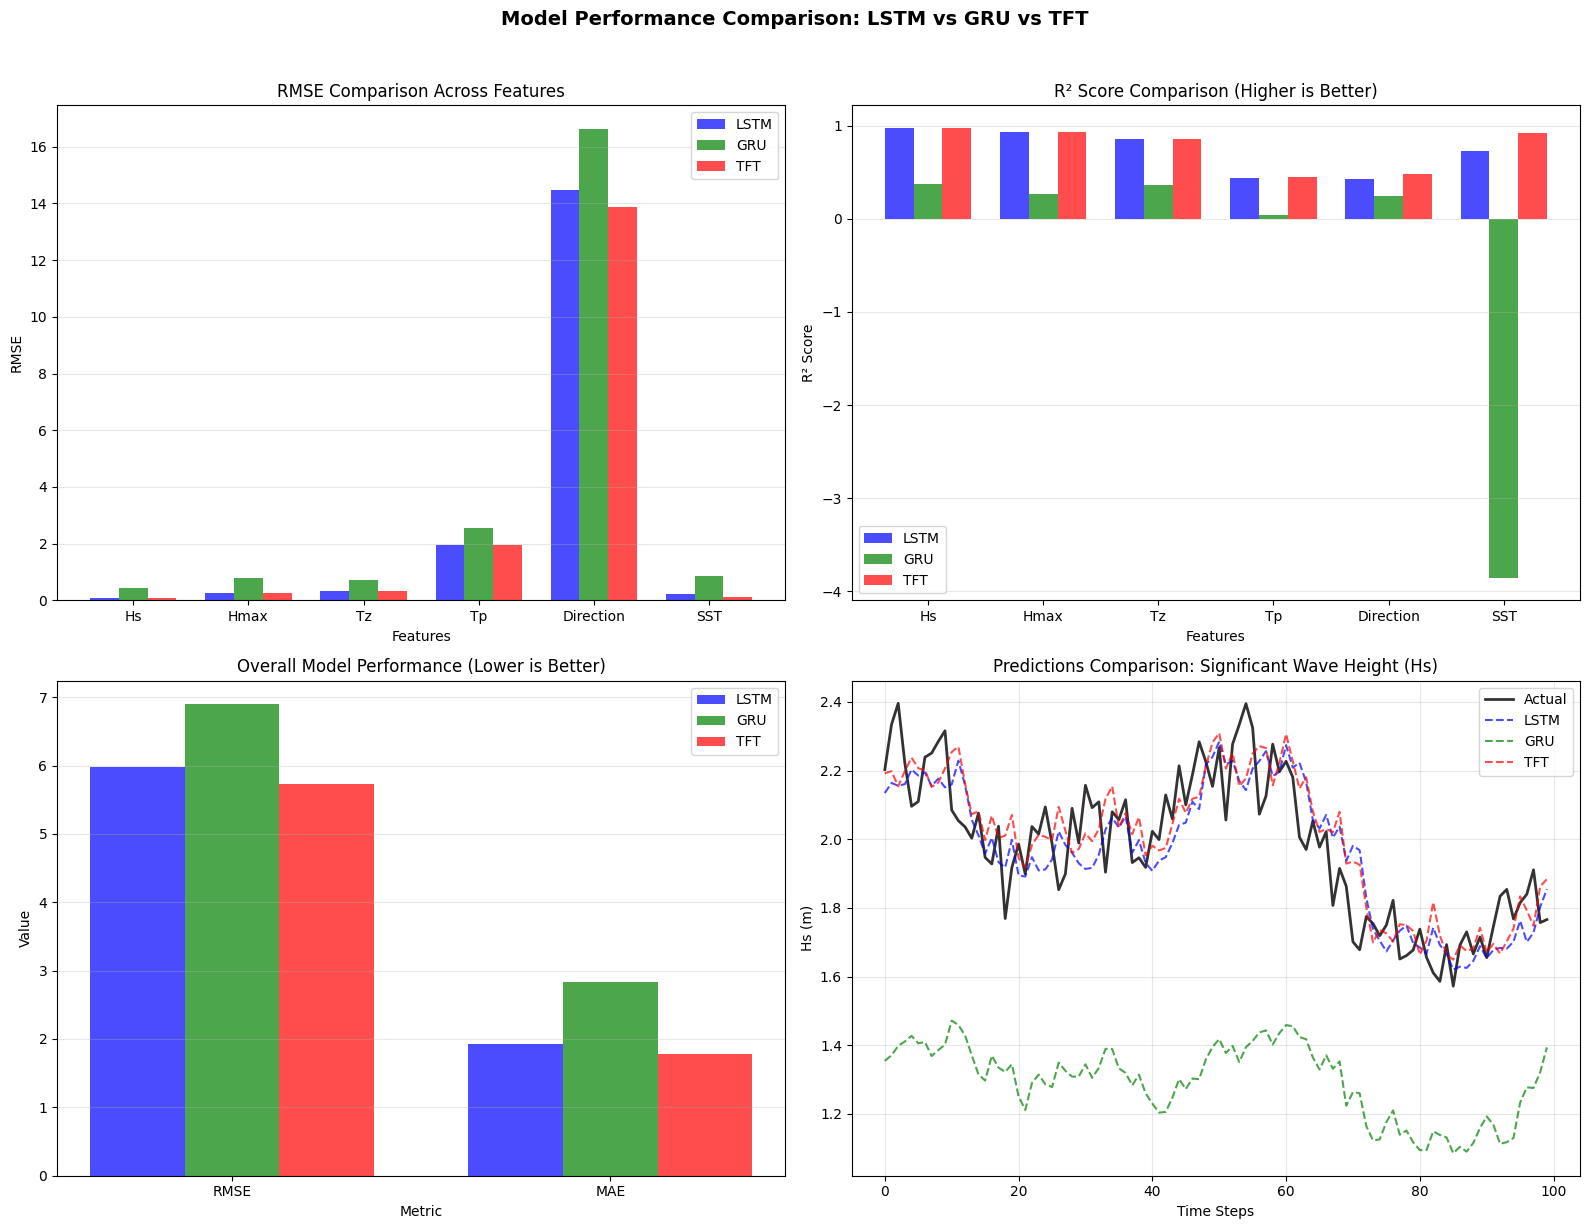

In [36]:
# =============================================================================
# VISUAL COMPARISON
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

feature_names_plot = ['Hs', 'Hmax', 'Tz', 'Tp', 'Direction', 'SST']

# Plot 1: RMSE Comparison Bar Chart
ax1 = axes[0, 0]
x = np.arange(len(feature_names_plot))
width = 0.25

lstm_rmse = [lstm_metrics[f]['RMSE'] for f in feature_names_plot]
gru_rmse = [gru_metrics[f]['RMSE'] for f in feature_names_plot]
tft_rmse = [tft_metrics[f]['RMSE'] for f in feature_names_plot]

bars1 = ax1.bar(x - width, lstm_rmse, width, label='LSTM', color='blue', alpha=0.7)
bars2 = ax1.bar(x, gru_rmse, width, label='GRU', color='green', alpha=0.7)
bars3 = ax1.bar(x + width, tft_rmse, width, label='TFT', color='red', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE Comparison Across Features')
ax1.set_xticks(x)
ax1.set_xticklabels(feature_names_plot)
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)

# Plot 2: R² Comparison Bar Chart
ax2 = axes[0, 1]
lstm_r2 = [lstm_metrics[f]['R2'] for f in feature_names_plot]
gru_r2 = [gru_metrics[f]['R2'] for f in feature_names_plot]
tft_r2 = [tft_metrics[f]['R2'] for f in feature_names_plot]

bars1 = ax2.bar(x - width, lstm_r2, width, label='LSTM', color='blue', alpha=0.7)
bars2 = ax2.bar(x, gru_r2, width, label='GRU', color='green', alpha=0.7)
bars3 = ax2.bar(x + width, tft_r2, width, label='TFT', color='red', alpha=0.7)

ax2.set_xlabel('Features')
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score Comparison (Higher is Better)')
ax2.set_xticks(x)
ax2.set_xticklabels(feature_names_plot)
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)

# Plot 3: Overall Metrics Comparison
ax3 = axes[1, 0]
metrics_names = ['RMSE', 'MAE']
x_metrics = np.arange(len(metrics_names))

lstm_overall = [lstm_metrics['Overall']['RMSE'], lstm_metrics['Overall']['MAE']]
gru_overall = [gru_metrics['Overall']['RMSE'], gru_metrics['Overall']['MAE']]
tft_overall = [tft_metrics['Overall']['RMSE'], tft_metrics['Overall']['MAE']]

bars1 = ax3.bar(x_metrics - width, lstm_overall, width, label='LSTM', color='blue', alpha=0.7)
bars2 = ax3.bar(x_metrics, gru_overall, width, label='GRU', color='green', alpha=0.7)
bars3 = ax3.bar(x_metrics + width, tft_overall, width, label='TFT', color='red', alpha=0.7)

ax3.set_xlabel('Metric')
ax3.set_ylabel('Value')
ax3.set_title('Overall Model Performance (Lower is Better)')
ax3.set_xticks(x_metrics)
ax3.set_xticklabels(metrics_names)
ax3.legend()
ax3.grid(True, axis='y', alpha=0.3)

# Plot 4: Predictions Comparison for Hs (sample)
ax4 = axes[1, 1]
sample_range = slice(1300, 1400)

ax4.plot(y_test[sample_range, 0], 'k-', label='Actual', linewidth=2, alpha=0.8)
ax4.plot(test_prediction[sample_range, 0], 'b--', label='LSTM', linewidth=1.5, alpha=0.7)
ax4.plot(test_pred_final[sample_range, 0], 'g--', label='GRU', linewidth=1.5, alpha=0.7)
ax4.plot(tft_prediction[sample_range, 0], 'r--', label='TFT', linewidth=1.5, alpha=0.7)

ax4.set_xlabel('Time Steps')
ax4.set_ylabel('Hs (m)')
ax4.set_title('Predictions Comparison: Significant Wave Height (Hs)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Model Performance Comparison: LSTM vs GRU vs TFT', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()